## 
Comparison of the Confidence Intervals computed by the simulate function provided by evgam (simulate), a traditional bootstrap method (Bootstrap) and a bootstrap method using the gev distribution (revd).

Methods are using a 1000 iterations.
##

In [10]:
import os

In [11]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import scipy
import cftime
import cartopy
import cartopy.crs as ccrs
import matplotlib.colors as colors
from copy import copy


In [12]:
from matplotlib import cm

In [13]:
state_borders =\
cartopy.feature.NaturalEarthFeature(category='cultural',\
        name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')

In [14]:
import warnings
warnings.filterwarnings('ignore')


# READ FILES

In [ ]:
yearb=1941
yeare=2025
B=1000

ifile=f'/gh_simulate_bootstrap_B{B}_1941_2025.nc'

dso = xr.open_dataset(ifile)
LocationDiff_q = dso['LocationDiff_q']
ScaleDiff_q = dso['ScaleDiff_q']
RLDiff_q = dso['RLDiff_q']
RiskRatios_q = dso['RiskRatios_q']
LocationDiff_qB = dso['LocationDiff_qGH']
ScaleDiff_qB = dso['ScaleDiff_qGH']
RLDiff_qB = dso['RLDiff_qGH']
RiskRatios_qB = dso['RiskRatios_qGH']

ifile=f'/gh_simulate_bootstrap_revd_B{B}_1941_2025.nc'
dso = xr.open_dataset(ifile)
LocationDiff_qR = dso['LocationDiff_qGH']
ScaleDiff_qR = dso['ScaleDiff_qGH']
RLDiff_qR = dso['RLDiff_qGH']
RiskRatios_qR = dso['RiskRatios_qGH']

Tlon = dso.lon.data
Tlat = dso.lat.data

units = 'degree-days (°C)'


In [16]:
Tlabels = [f'simulate, B={B}',f'Bootstrap, B={B}',f'revd, B={B}']
Tlocdiff = [LocationDiff_q,LocationDiff_qB,LocationDiff_qR]
Tscadiff = [ScaleDiff_q,ScaleDiff_qB,ScaleDiff_qR]
TRL = [RLDiff_q,RLDiff_qB,RLDiff_qR]
TRR = [RiskRatios_q,RiskRatios_qB,RiskRatios_qR]

In [17]:
vq=[0.95,0.05]
proj=ccrs.PlateCarree()
Tquantile=['0.95','0.05','0.95-0.05']


In [18]:
import cmaps

Text(0.5, 0.98, 'Difference 2025-1941 Return Level 100 year')

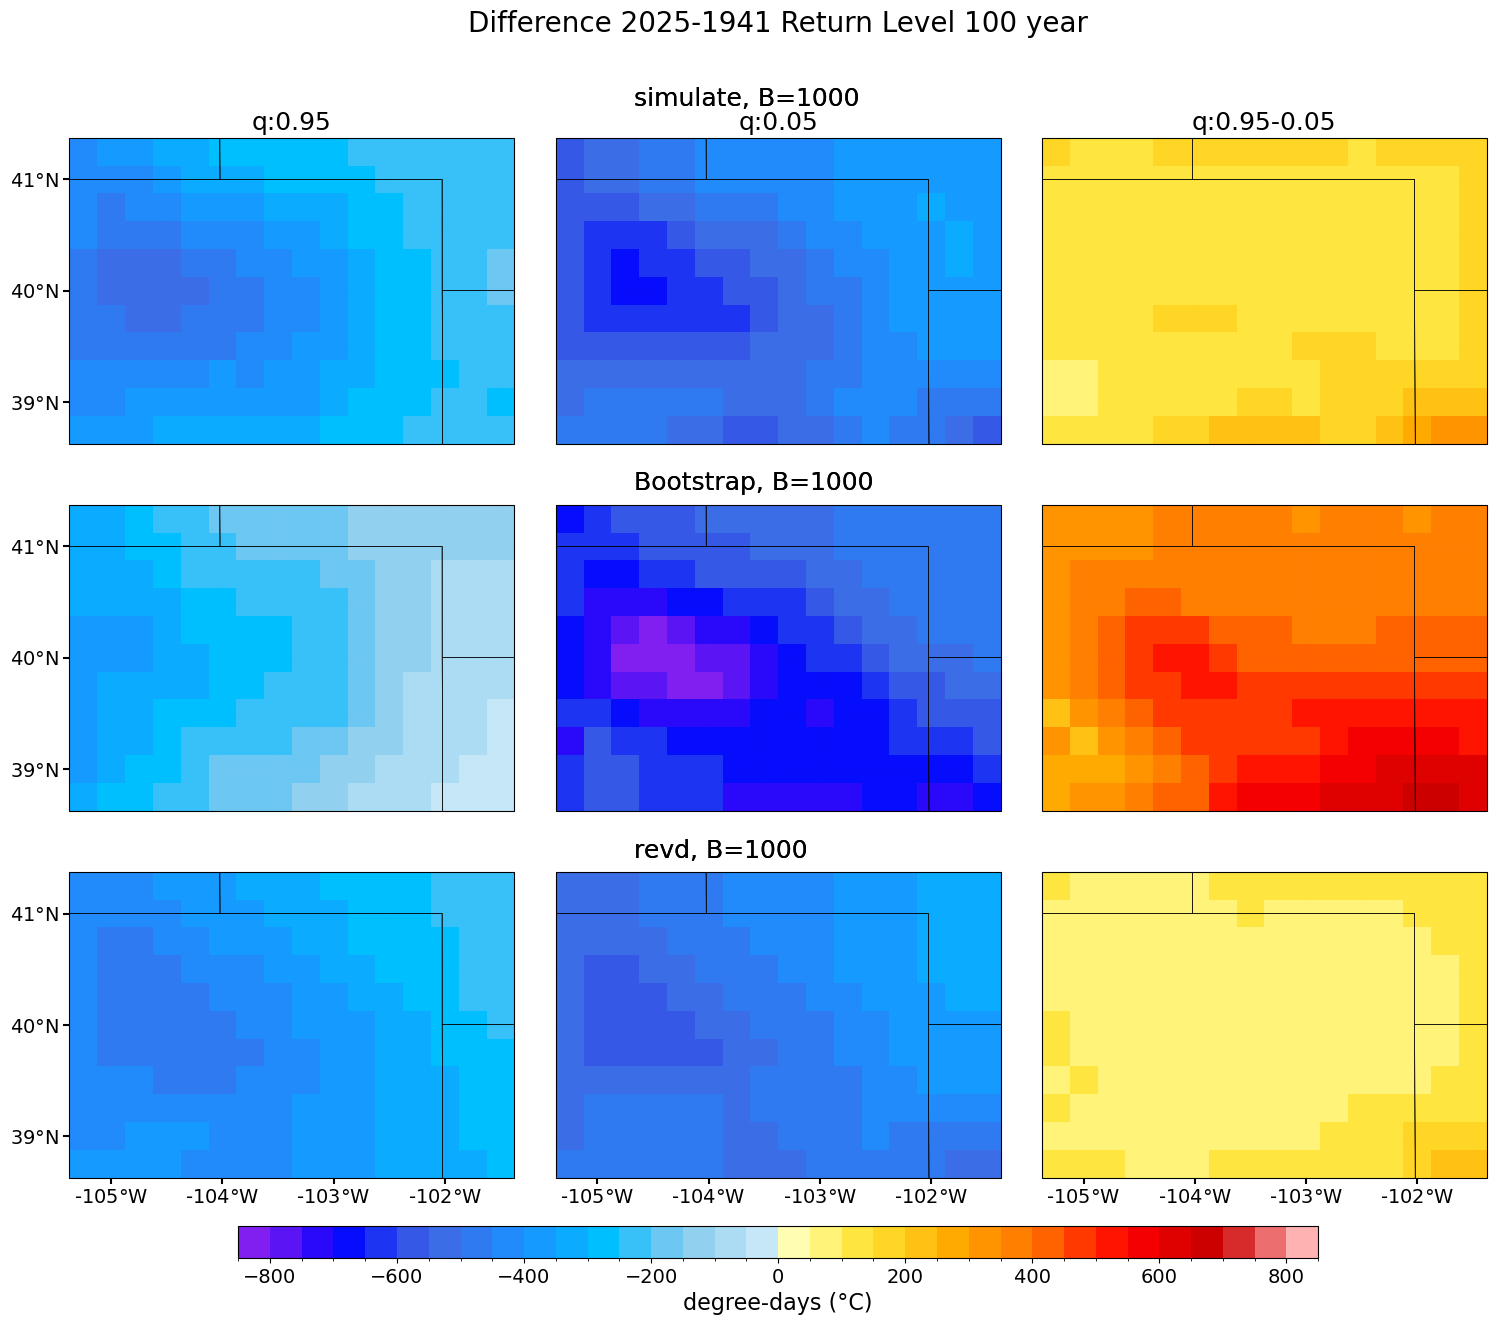

In [24]:
clevs = np.arange(-850,900,50)
cmap = cmaps.ncl_default

fig, ax = plt.subplots(nrows=3,ncols=len(Tquantile),figsize=(18,16),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.2,wspace=0.04)
ax = ax.flatten()
for ix in range(0,len(Tquantile)-1):
  cc = TRL[0].sel(quantile=vq[ix]).plot.pcolormesh(ax=ax[ix],levels=clevs,cmap=cmap,add_colorbar=False)
  cc = TRL[1].sel(quantile=vq[ix]).plot.pcolormesh(ax=ax[ix+3],levels=clevs,cmap=cmap,add_colorbar=False)
  cc = TRL[2].sel(quantile=vq[ix]).plot.pcolormesh(ax=ax[ix+2*3],levels=clevs,cmap=cmap,add_colorbar=False)
  fig.text(0.42,0.92,f'{Tlabels[0]}',fontsize=18)
  fig.text(0.42,0.68,f'{Tlabels[1]}',fontsize=18)
  fig.text(0.42,0.45,f'{Tlabels[2]}',fontsize=18)
  ax[ix].set_title(f'q:{Tquantile[ix]}',fontsize=18)   
  ax[ix+3].set_title(f'',fontsize=18)   
  ax[ix+2*3].set_title(f'',fontsize=18)   
##
ix=2
(TRL[0].sel(quantile=0.95)-TRL[0].sel(quantile=0.05)).plot.pcolormesh(ax=ax[ix],levels=clevs,cmap=cmap,add_colorbar=False)
(TRL[1].sel(quantile=0.95)-TRL[1].sel(quantile=0.05)).plot.pcolormesh(ax=ax[ix+3],levels=clevs,cmap=cmap,add_colorbar=False)
(TRL[2].sel(quantile=0.95)-TRL[2].sel(quantile=0.05)).plot.pcolormesh(ax=ax[ix+2*3],levels=clevs,cmap=cmap,add_colorbar=False)
ax[ix].set_title(f'q:{Tquantile[2]}',fontsize=18)   
ax[ix+3].set_title(f'',fontsize=18)   
ax[ix+2*3].set_title(f'',fontsize=18)   
##
for ix in range(0,len(ax)):
    ####
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()
  if ix >=len(ax)-3:
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)

for ix in range(0,len(ax),3): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.02])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'{units}',fontsize=16)

plt.suptitle(f'Difference {yeare}-{yearb} Return Level 100 year',fontsize=20)  

Text(0.5, 0.98, 'Difference 2025-1941 Location parameter')

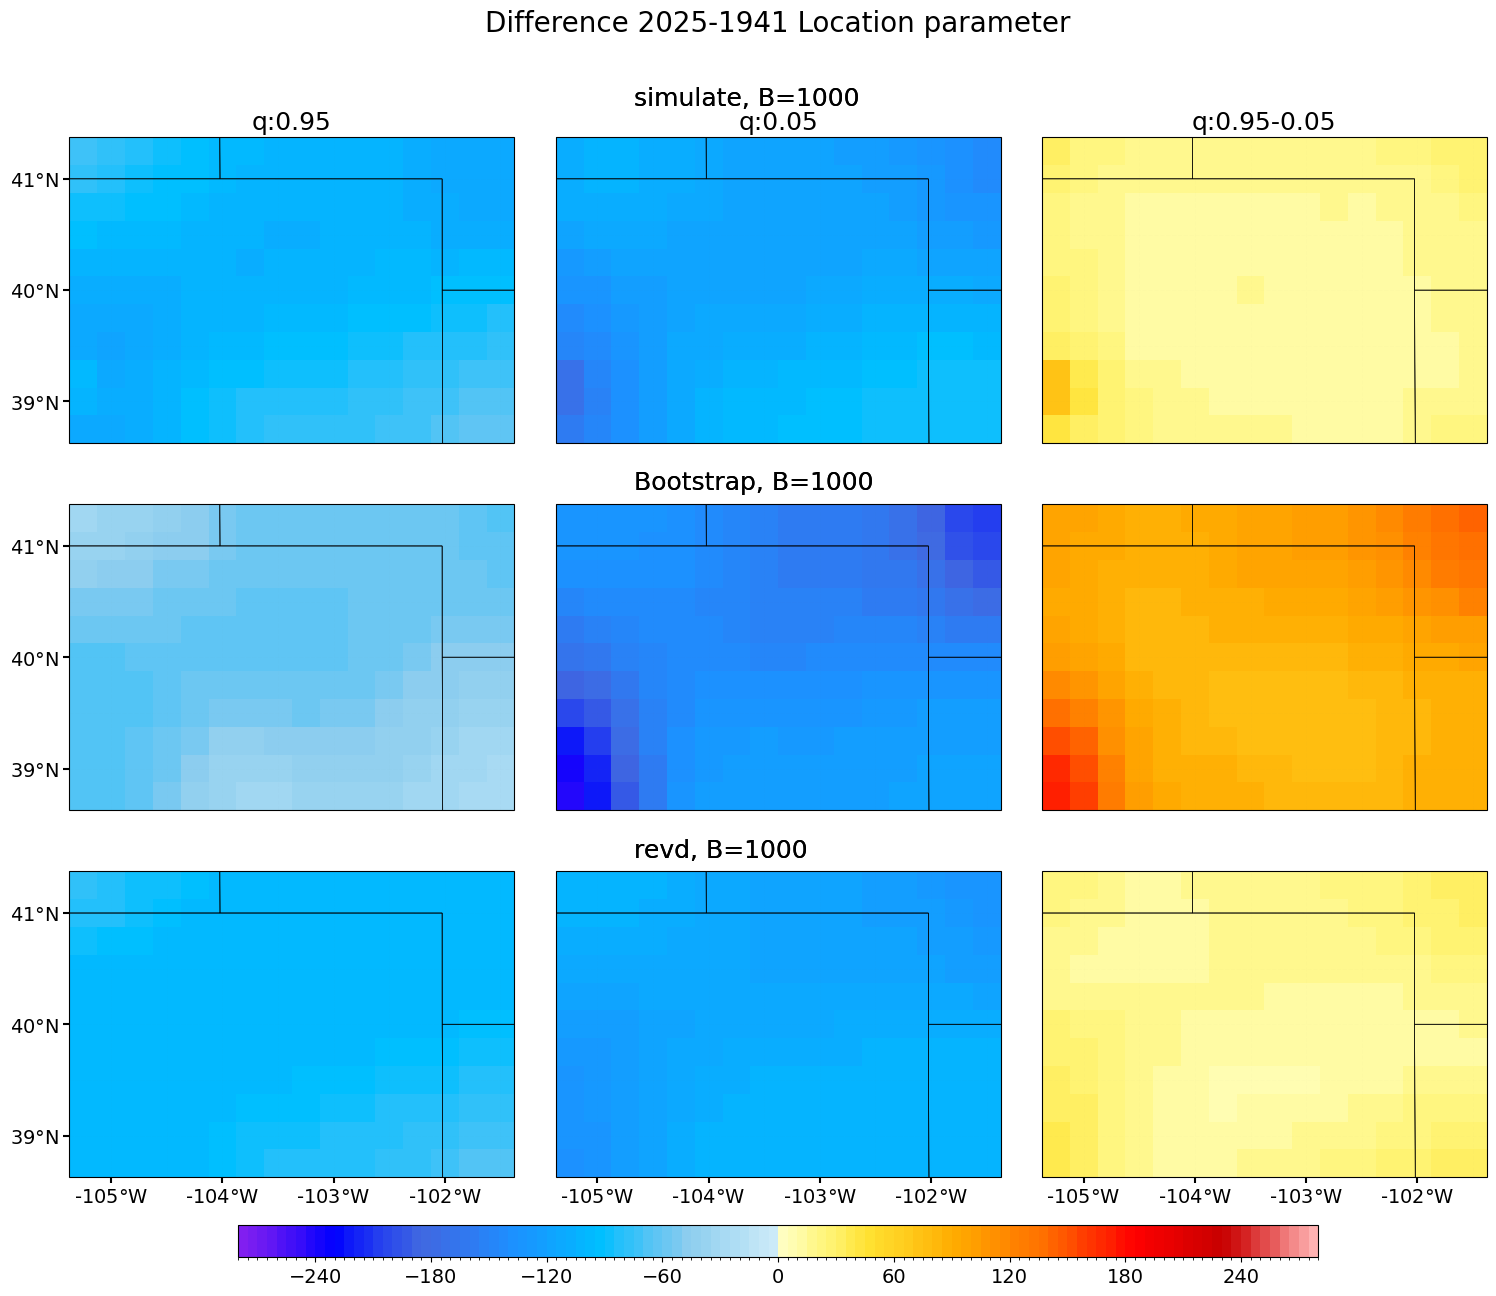

In [53]:
clevs = np.arange(-280,285,5)
cmap = cmaps.ncl_default

fig, ax = plt.subplots(nrows=3,ncols=len(Tquantile),figsize=(18,16),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.2,wspace=0.04)
ax = ax.flatten()

for ix in range(0,len(Tquantile)-1):
  cc = Tlocdiff[0].sel(quantile=vq[ix]).plot.pcolormesh(ax=ax[ix],levels=clevs,cmap=cmap,add_colorbar=False)
  cc = Tlocdiff[1].sel(quantile=vq[ix]).plot.pcolormesh(ax=ax[ix+3],levels=clevs,cmap=cmap,add_colorbar=False)
  cc = Tlocdiff[2].sel(quantile=vq[ix]).plot.pcolormesh(ax=ax[ix+2*3],levels=clevs,cmap=cmap,add_colorbar=False)
  fig.text(0.42,0.92,f'{Tlabels[0]}',fontsize=18)
  fig.text(0.42,0.68,f'{Tlabels[1]}',fontsize=18)
  fig.text(0.42,0.45,f'{Tlabels[2]}',fontsize=18)
  ax[ix].set_title(f'q:{Tquantile[ix]}',fontsize=18)   
  ax[ix+3].set_title(f'',fontsize=18)   
  ax[ix+2*3].set_title(f'',fontsize=18)   
##
ix=2
(Tlocdiff[0].sel(quantile=0.95)-Tlocdiff[0].sel(quantile=0.05)).plot.pcolormesh(ax=ax[ix],levels=clevs,cmap=cmap,add_colorbar=False)
(Tlocdiff[1].sel(quantile=0.95)-Tlocdiff[1].sel(quantile=0.05)).plot.pcolormesh(ax=ax[ix+3],levels=clevs,cmap=cmap,add_colorbar=False)
(Tlocdiff[2].sel(quantile=0.95)-Tlocdiff[2].sel(quantile=0.05)).plot.pcolormesh(ax=ax[ix+2*3],levels=clevs,cmap=cmap,add_colorbar=False)
ax[ix].set_title(f'q:{Tquantile[2]}',fontsize=18)   
ax[ix+3].set_title(f'',fontsize=18)   
ax[ix+2*3].set_title(f'',fontsize=18)   
for ix in range(0,len(ax)):
    ####
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()

  if ix >=len(ax)-3:
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)

for ix in range(0,len(ax),3): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.02])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'',fontsize=16)
plt.suptitle(f'Difference {yeare}-{yearb} Location parameter',fontsize=20)  

Text(0.5, 0.98, 'Difference 2025-1941 Scale parameter')

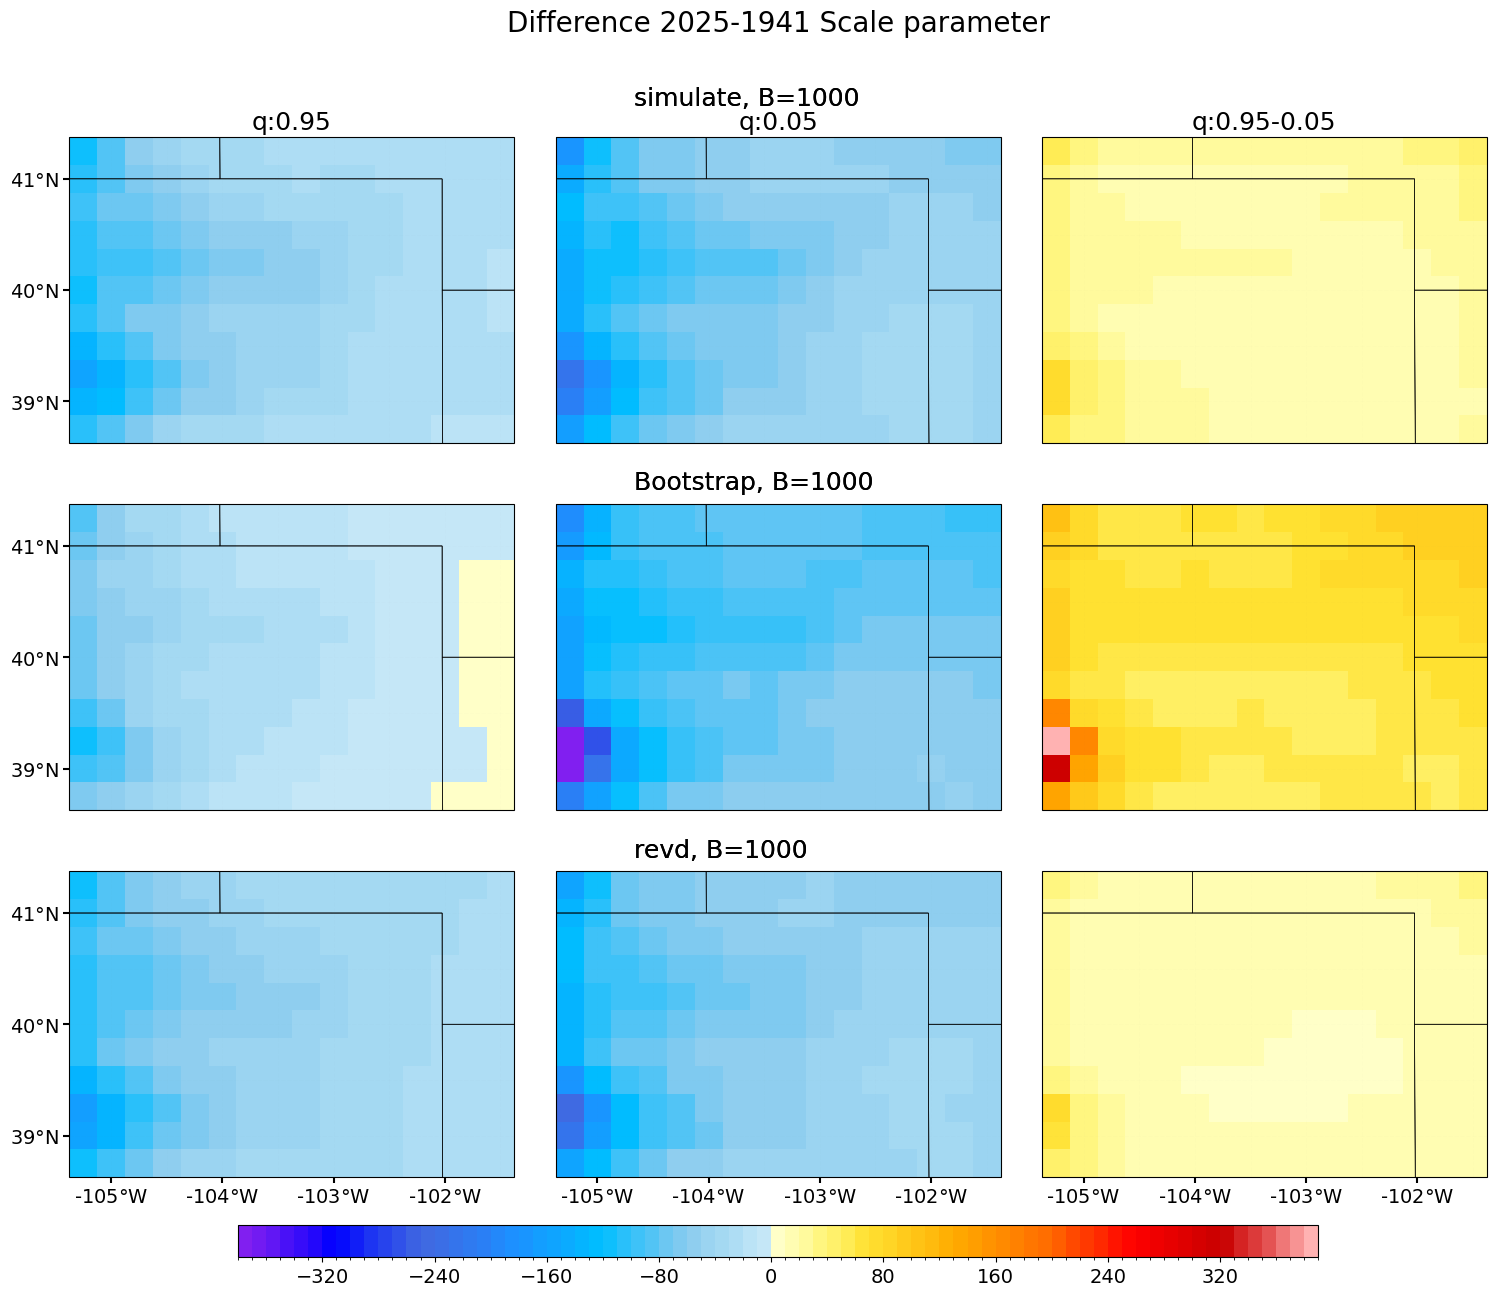

In [52]:
clevs = np.arange(-380,400,10)
cmap = cmaps.ncl_default

fig, ax = plt.subplots(nrows=3,ncols=len(Tquantile),figsize=(18,16),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.2,wspace=0.04)
ax = ax.flatten()

for ix in range(0,len(Tquantile)-1):
  cc = Tscadiff[0].sel(quantile=vq[ix]).plot.pcolormesh(ax=ax[ix],levels=clevs,cmap=cmap,add_colorbar=False)
  cc = Tscadiff[1].sel(quantile=vq[ix]).plot.pcolormesh(ax=ax[ix+3],levels=clevs,cmap=cmap,add_colorbar=False)
  cc = Tscadiff[2].sel(quantile=vq[ix]).plot.pcolormesh(ax=ax[ix+2*3],levels=clevs,cmap=cmap,add_colorbar=False)
  fig.text(0.42,0.92,f'{Tlabels[0]}',fontsize=18)
  fig.text(0.42,0.68,f'{Tlabels[1]}',fontsize=18)
  fig.text(0.42,0.45,f'{Tlabels[2]}',fontsize=18)
  ax[ix].set_title(f'q:{Tquantile[ix]}',fontsize=18)   
  ax[ix+3].set_title(f'',fontsize=18)   
  ax[ix+2*3].set_title(f'',fontsize=18)   
##
ix=2
(Tscadiff[0].sel(quantile=0.95)-Tscadiff[0].sel(quantile=0.05)).plot.pcolormesh(ax=ax[ix],levels=clevs,cmap=cmap,add_colorbar=False)
(Tscadiff[1].sel(quantile=0.95)-Tscadiff[1].sel(quantile=0.05)).plot.pcolormesh(ax=ax[ix+3],levels=clevs,cmap=cmap,add_colorbar=False)
(Tscadiff[2].sel(quantile=0.95)-Tscadiff[2].sel(quantile=0.05)).plot.pcolormesh(ax=ax[ix+2*3],levels=clevs,cmap=cmap,add_colorbar=False)
ax[ix].set_title(f'q:{Tquantile[2]}',fontsize=18)   
ax[ix+3].set_title(f'',fontsize=18)   
ax[ix+2*3].set_title(f'',fontsize=18)   
for ix in range(0,len(ax)):
    ####
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()

  if ix >=len(ax)-3:
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)

for ix in range(0,len(ax),3): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.02])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'',fontsize=16)
plt.suptitle(f'Difference {yeare}-{yearb} Scale parameter',fontsize=20)  

In [50]:
from matplotlib import cm
## Build colorbar
clevsa=np.arange(1.,64,2)
clevsb=np.arange(0,1.1,1)
rr_clevs=np.concatenate((clevsb,clevsa))
cmap = cm.get_cmap('YlOrBr',len(clevsa))
cmaplist = [cmap(i) for i in range(0,cmap.N)]
cmap2 = cm.get_cmap('Blues_r', len(clevsb)+5)
cmaplist2 = [cmap2(i) for i in range(3,cmap2.N-2)]

rr_cmap = colors.LinearSegmentedColormap.from_list('Custom cmap',\
                cmaplist2+cmaplist, len(cmaplist2)+len(cmaplist))

##########
##########

Text(0.5, 0.98, 'Risk ratios')

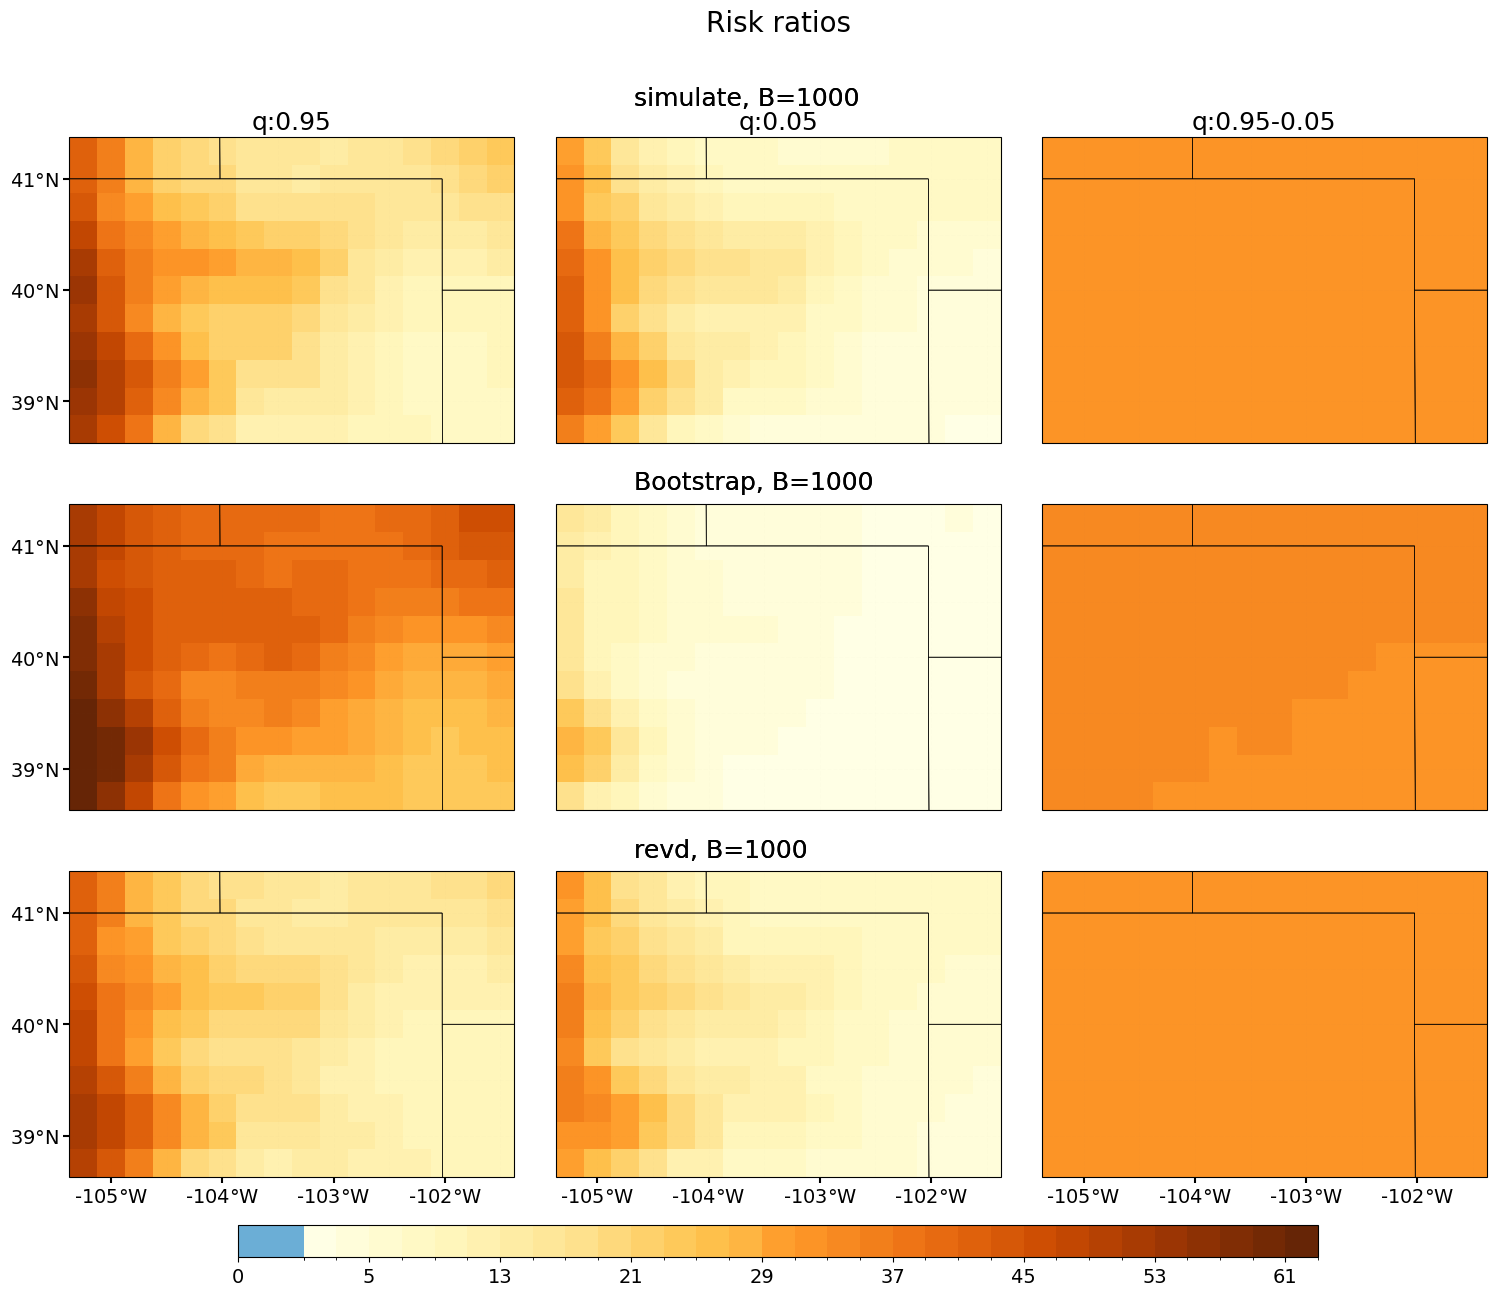

In [51]:
fig, ax = plt.subplots(nrows=3,ncols=len(Tquantile),figsize=(18,16),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.2,wspace=0.04)
ax = ax.flatten()

for ix in range(0,len(Tquantile)-1):
  cc = TRR[0].sel(quantile=vq[ix]).plot.pcolormesh(ax=ax[ix],cmap=rr_cmap,levels=rr_clevs,add_colorbar=False)
  cc = TRR[1].sel(quantile=vq[ix]).plot.pcolormesh(ax=ax[ix+3],cmap=rr_cmap,levels=rr_clevs,add_colorbar=False)
  cc = TRR[2].sel(quantile=vq[ix]).plot.pcolormesh(ax=ax[ix+2*3],cmap=rr_cmap,levels=rr_clevs,add_colorbar=False)
  fig.text(0.42,0.92,f'{Tlabels[0]}',fontsize=18)
  fig.text(0.42,0.68,f'{Tlabels[1]}',fontsize=18)
  fig.text(0.42,0.45,f'{Tlabels[2]}',fontsize=18)
  ax[ix].set_title(f'q:{Tquantile[ix]}',fontsize=18)   
  ax[ix+3].set_title(f'',fontsize=18)   
  ax[ix+2*3].set_title(f'',fontsize=18)   
##
ix=2
(TRR[0].sel(quantile=0.95)-TRR[0].sel(quantile=0.05)).plot.pcolormesh(ax=ax[ix],levels=clevs,cmap=cmap,add_colorbar=False)
(TRR[1].sel(quantile=0.95)-TRR[1].sel(quantile=0.05)).plot.pcolormesh(ax=ax[ix+3],levels=clevs,cmap=cmap,add_colorbar=False)
(TRR[2].sel(quantile=0.95)-TRR[2].sel(quantile=0.05)).plot.pcolormesh(ax=ax[ix+2*3],levels=clevs,cmap=cmap,add_colorbar=False)
ax[ix].set_title(f'q:{Tquantile[2]}',fontsize=18)   
ax[ix+3].set_title(f'',fontsize=18)   
ax[ix+2*3].set_title(f'',fontsize=18)   
for ix in range(0,len(ax)):
    ####
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()

  if ix >=len(ax)-3:
    ax[ix].set_xticks(ax[ix].get_xticks()[1:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)

for ix in range(0,len(ax),3): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.02])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'',fontsize=16)
plt.suptitle(f'Risk ratios',fontsize=20)  